#  Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Load Data and Basic Cleaning

In [2]:
# Load the CSV
df = pd.read_csv(r"D:\BI_NI_CI\ModelAllData.csv")

# Basic cleaning
df['Miladi'] = pd.to_datetime(df['Miladi'], errors='coerce')
df = df.dropna(subset=['Miladi', 'GoodsID', 'MainQty'])

# Ensure numeric quantity
df['MainQty'] = pd.to_numeric(df['MainQty'], errors='coerce').fillna(0)

C:\Users\M Zafar\AppData\Local\Temp\ipykernel_22360\3424927562.py:2: DtypeWarning: Columns (1,18,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\BI_NI_CI\ModelAllData.csv")


# Feature Engineering

In [3]:
df[df['GoodsID']>500000]

,GoodsID,Code,Name,jdate,Miladi,Quarter,IsHoliday,MainQty,Price,Group1CarsManufacturer,...,Group6Material,Group7Color,Group8Size,Group9Property,Group10Presenter,Group11Brand,Group12,Group13,Group14,Group15


In [4]:
unique_goods_name=df[['GoodsID','Name']].drop_duplicates()
unique_goods_name[unique_goods_name.duplicated('GoodsID', keep=False)]

,GoodsID,Name
1601,59780.0,دوبل سینی جلو پیکان بی نی سی (بی نی سی Bi Ni Ci)
7010,70879.0,نصفه شاسی بلند جلو راست سمند بی نی سی (بی نی س...
16224,70871.0,نصفه شاسی بلند جلو راست پژو 405 بی نی سی (بی ن...
23750,71570.0,"واشر منیفولد دود تیبا سایپا P13 (P13, سایپا SA..."
25089,51197.0,سپر جلو دیاق پژو 405 بی نی سی مهرخواه (بی نی س...
...,...,...
1434747,75608.0,قاب سنسور دنده عقب سازه پویش رانا (کروز CROUSE)
1440388,79717.0,دور فرمان وسط سوزنی (مشکی قرمز)
1440392,79717.0,تیغه برف پاک کن جلو ال 90 PIYER (PIYER)
1440433,79724.0,تیغه برف پاک کن جلو پراید PIYER (PIYER)


In [5]:
unique_goods_name_code=df[['Code','Name']].drop_duplicates()
unique_goods_name_code[unique_goods_name_code.duplicated('Code', keep=False)]

,Code,Name
25089,19163,سپر جلو دیاق پژو 405 بی نی سی مهرخواه (بی نی س...
434185,19218,"سپر عقب سفید پژو 206 مهرخواه (سفید, مهرخواه ME..."
453030,15579,"دستگاه بالابر جلو چپ سمند ایساکو i99 (i99, ایس..."
802632,30840,"کابل کلاچ وزنه دار پراید سایپا P91 (P91, سایپا..."
980635,31263,کامپیوتر بوش ME17 پژو 405 عظام (عظام EZAM)
1007217,28696,"پمپ هیدرولیک H30 CROSS ایساکو i02 (i02, ایساکو..."
1046261,13691,جلو پنجره با زه تارا
1094797,12813,تسمه هیدرولیک 1335 آریسان ایساکو OPTIBELT O12 ...
1099673,31981,کمک فنر جلو اسپرت پژو 206 کوشاوران (کوشاوران K...
1100064,21385,"طاقچه عقب تیبا 2 هاچ بک سایپا P6S (P6S, سایپا ..."


In [6]:
df['Code'].drop_duplicates()


0          28306
22         10660
60         11670
92         29612
110        28473
           ...  
1441561    36494
1441562    36497
1441563    36501
1441564    36531
1441565    36533
Name: Code, Length: 37971, dtype: object

In [7]:
df['Name'].drop_duplicates()

0          پتانسیومتر دریچه گاز ساژم پیکان دناکو (دناکو D...
22                                آینه راست پیکان وانت باردو
60                           باک بنزین کاربراتوری رنگی پیکان
92                                    پیچ سپر جلو 7*12 پیکان
110                                           پل کوتاه پیکان
                                 ...                        
1441561    صافی بنزین سر کج پراید LOCO MOBIL (لوکو مبیل L...
1441562                            براکت سپر جلو چپ EFP سمند
1441563                                   گلگیر عقب چپ ساینا
1441564             صندلی کامل طرح ناتیس پژو 206 (طرح ناتیس)
1441565    پولی جلو میل لنگ پژو 206 تیپ 5 آسیا صنعت (آسیا...
Name: Name, Length: 24289, dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1380391 entries, 0 to 1441565
Data columns (total 24 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   GoodsID                 1380391 non-null  float64       
 1   Code                    1380391 non-null  object        
 2   Name                    1380391 non-null  object        
 3   jdate                   1380391 non-null  object        
 4   Miladi                  1380391 non-null  datetime64[ns]
 5   Quarter                 1380391 non-null  int64         
 6   IsHoliday               1380391 non-null  int64         
 7   MainQty                 1380391 non-null  float64       
 8   Price                   1380391 non-null  float64       
 9   Group1CarsManufacturer  1296357 non-null  object        
 10  Group2CarsGroup         1213779 non-null  object        
 11  Group3CarsModel         1127641 non-null  object        
 12  Group4GoodsType    

In [9]:
df.describe(include="all")

,GoodsID,Code,Name,jdate,Miladi,Quarter,IsHoliday,MainQty,Price,Group1CarsManufacturer,...,Group6Material,Group7Color,Group8Size,Group9Property,Group10Presenter,Group11Brand,Group12,Group13,Group14,Group15
count,1.380391e+06,1380391,1380391,1380391,1380391,1.380391e+06,1380391.0,1.380391e+06,1.380391e+06,1296357,...,1193796,1137293,1118940,1114154,881116,1133328,0.0,1290295,93138,1356845
unique,NaN,37971,24289,1196,NaN,NaN,NaN,NaN,NaN,13,...,42,67,281,477,6,775,NaN,501,11,21305
top,NaN,21267,"ضد یخ کاسپین (1 لیتری, کاسپین CASPIAN)",1402/11/03,NaN,NaN,NaN,NaN,NaN,ایران خودرو,...,Nan,هيچکدام,هيچکدام,هيچکدام,بازاري,Nan,NaN,چراغ,تریم داخلی,ضد یخ 1 لیتری کاسپین
freq,NaN,910,1181,2713,NaN,NaN,NaN,NaN,NaN,417341,...,412178,600103,609527,506412,370038,311323,NaN,52844,34412,1181
mean,6.258791e+04,NaN,NaN,NaN,2024-04-16 13:07:00.060982528,2.552744e+00,0.0,1.887159e+00,7.129466e+06,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,5.060800e+04,NaN,NaN,NaN,2022-06-24 00:00:00,1.000000e+00,0.0,-2.980000e+02,-4.125000e+08,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,5.682700e+04,NaN,NaN,NaN,2023-07-16 00:00:00,2.000000e+00,0.0,1.000000e+00,5.800000e+05,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,6.279600e+04,NaN,NaN,NaN,2024-05-15 00:00:00,3.000000e+00,0.0,1.000000e+00,2.000000e+06,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,6.821700e+04,NaN,NaN,NaN,2025-02-02 00:00:00,3.000000e+00,0.0,2.000000e+00,6.700000e+06,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,8.047600e+04,NaN,NaN,NaN,2025-11-17 00:00:00,4.000000e+00,0.0,3.002000e+03,3.400000e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.isna().sum()

GoodsID                         0
Code                            0
Name                            0
jdate                           0
Miladi                          0
Quarter                         0
IsHoliday                       0
MainQty                         0
Price                           0
Group1CarsManufacturer      84034
Group2CarsGroup            166612
Group3CarsModel            252750
Group4GoodsType             81602
Group5Arrow                199996
Group6Material             186595
Group7Color                243098
Group8Size                 261451
Group9Property             266237
Group10Presenter           499275
Group11Brand               247063
Group12                   1380391
Group13                     90096
Group14                   1287253
Group15                     23546
dtype: int64

## Basics

In [11]:

# Feature engineering (daily level)
df['year'] = df['Miladi'].dt.year
df['month'] = df['Miladi'].dt.month
df['quarter'] = df['Miladi'].dt.quarter

# convert IsHoliday to numeric
df['IsHoliday'] = df['IsHoliday'].astype(int)

## Aggregates

In [12]:
# Aggregate per month per GoodsID
monthly = (
    df.groupby(['GoodsID', 'year', 'month', 'quarter'], as_index=False)
      .agg({'MainQty': 'sum', 'Price': 'mean'})
)

# Create a proper datetime for each month (using first day of month)
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))

# Create lag features
monthly = monthly.sort_values(['GoodsID', 'date'])

# 24 months Lags
LAGS = list(range(1,25))
lag_features=[]

for lag in LAGS:
    monthly[f'lag_{lag}'] = monthly.groupby('GoodsID')['MainQty'].shift(lag)
    lag_features.append(f'lag_{lag}')

# Rolling features
ROLLINGS = [3,6,9,12]
rolling_features=[]
for rol in ROLLINGS:
    monthly[f'rolling_{rol}'] = (
        monthly.groupby('GoodsID')['MainQty']
        .transform(lambda x: x.shift(1).rolling(rol).mean())
    )
    rolling_features.append(f'rolling_{rol}')

# Drop rows with all null features
monthly = monthly.dropna(how='all', subset=lag_features + rolling_features).reset_index(drop=True)

all_features = lag_features + rolling_features + ['Price', 'year', 'month', 'quarter']

## Filter based on lags

In [29]:
monthly.sort_values(['GoodsID', 'year', 'month'])

,GoodsID,year,month,quarter,MainQty,Price,date,lag_1,lag_2,lag_3,...,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_3,rolling_6,rolling_9,rolling_12
0,50718.0,2023,7,3,25.0,8.362571e+06,2023-07-01,15.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50718.0,2023,8,3,7.0,6.650000e+06,2023-08-01,25.0,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,50718.0,2023,9,3,13.0,7.410000e+06,2023-09-01,7.0,25.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,15.666667,NaN,NaN,NaN
3,50718.0,2023,10,4,5.0,9.500000e+06,2023-10-01,13.0,7.0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,NaN,NaN,NaN
4,50718.0,2023,11,4,28.0,1.140000e+07,2023-11-01,5.0,13.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,8.333333,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61477,74269.0,2025,4,2,2.0,1.243000e+07,2025-04-01,2.0,4.0,19.0,...,12.0,12.0,16.0,4.0,8.0,0.0,8.333333,9.333333,9.333333,8.750000
61478,74269.0,2025,8,3,2.0,3.270000e+07,2025-08-01,2.0,2.0,4.0,...,14.0,12.0,12.0,16.0,4.0,8.0,2.666667,7.833333,8.777778,8.250000
61479,74269.0,2025,9,3,3.0,1.287562e+07,2025-09-01,2.0,2.0,2.0,...,11.0,14.0,12.0,12.0,16.0,4.0,2.000000,6.666667,8.000000,8.166667
61480,74269.0,2025,10,4,5.0,1.802600e+07,2025-10-01,3.0,2.0,2.0,...,23.0,11.0,14.0,12.0,12.0,16.0,2.333333,5.333333,7.000000,7.583333


In [14]:
good_history_goods=monthly[~monthly['lag_12'].isna()]['GoodsID'].drop_duplicates()
good_history_goods

43        50612.0
80        50622.0
285       50677.0
508       50718.0
568       50729.0
           ...   
301377    74197.0
301390    74198.0
301437    74203.0
301524    74223.0
301704    74269.0
Name: GoodsID, Length: 10338, dtype: float64

In [15]:
monthly=pd.merge(good_history_goods, monthly, on='GoodsID', how='inner')

In [16]:
monthly[~monthly['lag_8'].isna()]

,GoodsID,year,month,quarter,MainQty,Price,date,lag_1,lag_2,lag_3,...,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_3,rolling_6,rolling_9,rolling_12
7,50612.0,2023,2,1,4.0,1.612500e+07,2023-02-01,5.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,3.166667,NaN,NaN
8,50612.0,2023,3,1,2.0,1.980000e+07,2023-03-01,4.0,5.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,3.666667,2.833333,3.111111,NaN
9,50612.0,2023,4,2,3.0,1.980000e+07,2023-04-01,2.0,4.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,3.666667,2.833333,3.222222,NaN
10,50612.0,2023,6,2,3.0,2.683348e+07,2023-06-01,3.0,2.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,3.000000,3.111111,NaN
11,50612.0,2023,7,3,6.0,2.940000e+07,2023-07-01,3.0,3.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2.666667,3.166667,2.777778,3.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248444,74269.0,2025,4,2,2.0,1.243000e+07,2025-04-01,2.0,4.0,19.0,...,12.0,12.0,16.0,4.0,8.0,0.0,8.333333,9.333333,9.333333,8.750000
248445,74269.0,2025,8,3,2.0,3.270000e+07,2025-08-01,2.0,2.0,4.0,...,14.0,12.0,12.0,16.0,4.0,8.0,2.666667,7.833333,8.777778,8.250000
248446,74269.0,2025,9,3,3.0,1.287562e+07,2025-09-01,2.0,2.0,2.0,...,11.0,14.0,12.0,12.0,16.0,4.0,2.000000,6.666667,8.000000,8.166667
248447,74269.0,2025,10,4,5.0,1.802600e+07,2025-10-01,3.0,2.0,2.0,...,23.0,11.0,14.0,12.0,12.0,16.0,2.333333,5.333333,7.000000,7.583333


In [28]:
monthly[~monthly['lag_18'].isna()]['GoodsID'].unique()

array([50718., 50729., 50923., ..., 74044., 74150., 74269.])

In [18]:
monthly.GoodsID.nunique()

10338

## Filter based on average sales

In [19]:
avg_sales= monthly.groupby('GoodsID')['MainQty'].mean().rename('avg').reset_index()
avg_sales

,GoodsID,avg
0,50612.0,2.720000
1,50622.0,2.277778
2,50677.0,3.772727
3,50718.0,20.944444
4,50729.0,19.650000
...,...,...
10333,74197.0,1.076923
10334,74198.0,3.173913
10335,74203.0,7.083333
10336,74223.0,2.500000


In [20]:
avg_sales.describe(percentiles=[.1, .2, .5, .8, .9])

,GoodsID,avg
count,10338.000000,10338.000000
mean,62484.216967,7.888154
std,6171.438857,21.049196
min,50612.000000,0.000000
10%,54080.700000,1.307692
20%,56201.400000,1.636364
50%,62568.500000,3.105263
80%,68735.200000,8.333333
90%,70963.200000,16.159375
max,74269.000000,708.951220


<Axes: >

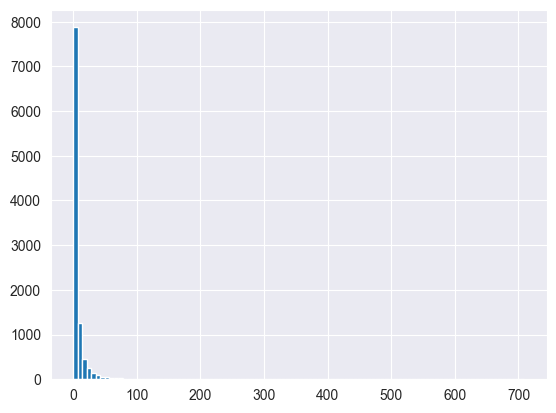

In [21]:
avg_sales['avg'].hist(bins=100)

In [22]:
monthly_sales_threshold = 8
high_sales_goods = avg_sales[avg_sales['avg']>monthly_sales_threshold]['GoodsID']
low_sales_goods = avg_sales[avg_sales['avg']<=monthly_sales_threshold]['GoodsID']
high_sales_goods

3        50718.0
4        50729.0
10       50907.0
12       50923.0
21       51063.0
          ...   
10322    74044.0
10327    74060.0
10328    74067.0
10332    74150.0
10337    74269.0
Name: GoodsID, Length: 2143, dtype: float64

In [23]:
monthly=pd.merge(high_sales_goods, monthly, on='GoodsID', how='inner')

# Train/Test Split

In [24]:
# Prepare training data
# Features: lag, rolling stats, price, year, month, quarter
feature_cols = all_features
X = monthly[feature_cols]
y = monthly['MainQty']

# Train/test split (chronological)
# last 2 months as test
split_date = monthly['date'].max() - pd.DateOffset(months=2)
train_idx = monthly['date'] <= split_date
test_idx = monthly['date'] > split_date

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

In [26]:
monthly

,GoodsID,year,month,quarter,MainQty,Price,date,lag_1,lag_2,lag_3,...,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_3,rolling_6,rolling_9,rolling_12
0,50718.0,2023,7,3,25.0,8.362571e+06,2023-07-01,15.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50718.0,2023,8,3,7.0,6.650000e+06,2023-08-01,25.0,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,50718.0,2023,9,3,13.0,7.410000e+06,2023-09-01,7.0,25.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,15.666667,NaN,NaN,NaN
3,50718.0,2023,10,4,5.0,9.500000e+06,2023-10-01,13.0,7.0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,NaN,NaN,NaN
4,50718.0,2023,11,4,28.0,1.140000e+07,2023-11-01,5.0,13.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,8.333333,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61477,74269.0,2025,4,2,2.0,1.243000e+07,2025-04-01,2.0,4.0,19.0,...,12.0,12.0,16.0,4.0,8.0,0.0,8.333333,9.333333,9.333333,8.750000
61478,74269.0,2025,8,3,2.0,3.270000e+07,2025-08-01,2.0,2.0,4.0,...,14.0,12.0,12.0,16.0,4.0,8.0,2.666667,7.833333,8.777778,8.250000
61479,74269.0,2025,9,3,3.0,1.287562e+07,2025-09-01,2.0,2.0,2.0,...,11.0,14.0,12.0,12.0,16.0,4.0,2.000000,6.666667,8.000000,8.166667
61480,74269.0,2025,10,4,5.0,1.802600e+07,2025-10-01,3.0,2.0,2.0,...,23.0,11.0,14.0,12.0,12.0,16.0,2.333333,5.333333,7.000000,7.583333


# Model training and Hyperparameter Tuning

In [25]:
tscv = TimeSeriesSplit(n_splits=3)

xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=3
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


KeyboardInterrupt: 

# Evaluation

In [313]:
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")


MAE: 13.50
RMSE: 32.94
R²: 0.511


# Forcast Next Month

In [314]:

# Forecast for each GoodsID for the next month
latest_date = monthly['date'].max()
forecast_month = latest_date + pd.DateOffset(months=1)

latest_features = (
    monthly.sort_values(['GoodsID', 'date'])
    .groupby('GoodsID')
    .tail(1)[['GoodsID'] + feature_cols]
)

latest_features['forecast_month'] = forecast_month
latest_features['predicted_next_month'] = best_model.predict(latest_features[feature_cols])

latest_features[['GoodsID', 'forecast_month', 'predicted_next_month']]


,GoodsID,forecast_month,predicted_next_month
17,50718.0,2025-12-01,39.325401
37,50729.0,2025-12-01,38.605175
52,50907.0,2025-12-01,24.166054
77,50923.0,2025-12-01,25.241167
96,51063.0,2025-12-01,12.880995
...,...,...,...
61375,74044.0,2025-12-01,20.464769
61388,74060.0,2025-12-01,13.038419
61403,74067.0,2025-12-01,8.798650
61443,74150.0,2025-12-01,12.068937


In [315]:
def plot_historical_and_predictions(target_goodsid):

    # Prepare historical + prediction data
    product_df = monthly[monthly['GoodsID'] == target_goodsid].copy()
    product_df = product_df.sort_values('date')

    # Predict on all available months
    product_df['predicted'] = best_model.predict(product_df[feature_cols])

    # Prepare next-month forecast (if available)
    forecast_row = latest_features[latest_features['GoodsID'] == target_goodsid]

    # Plot
    plt.figure(figsize=(12,6))

    # Actual sales (ground truth)
    plt.plot(
        product_df['date'],
        product_df['MainQty'],
        label='Actual Sales',
        marker='o',
        color='steelblue',
    )

    # Model predictions (train + test)
    plt.plot(
        product_df['date'],
        product_df['predicted'],
        label='Model Prediction',
        linestyle='--',
        marker='.',
        color='orange',
    )

    # Add forecast for next month (if available)
    if not forecast_row.empty:
        plt.scatter(
            forecast_row['forecast_month'],
            forecast_row['predicted_next_month'],
            color='red',
            s=120,
            marker='*',
            label='Next Month Forecast'
        )

    # Visual split marker
    plt.axvline(split_date, color='gray', linestyle=':', label='Train/Test Split')

    # Labels and formatting
    plt.title(f"GoodsID {target_goodsid} — Historical, Predicted, and Forecasted Sales")
    plt.xlabel("Date")
    plt.ylabel("Sales Quantity")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


GoodId = 62949.0


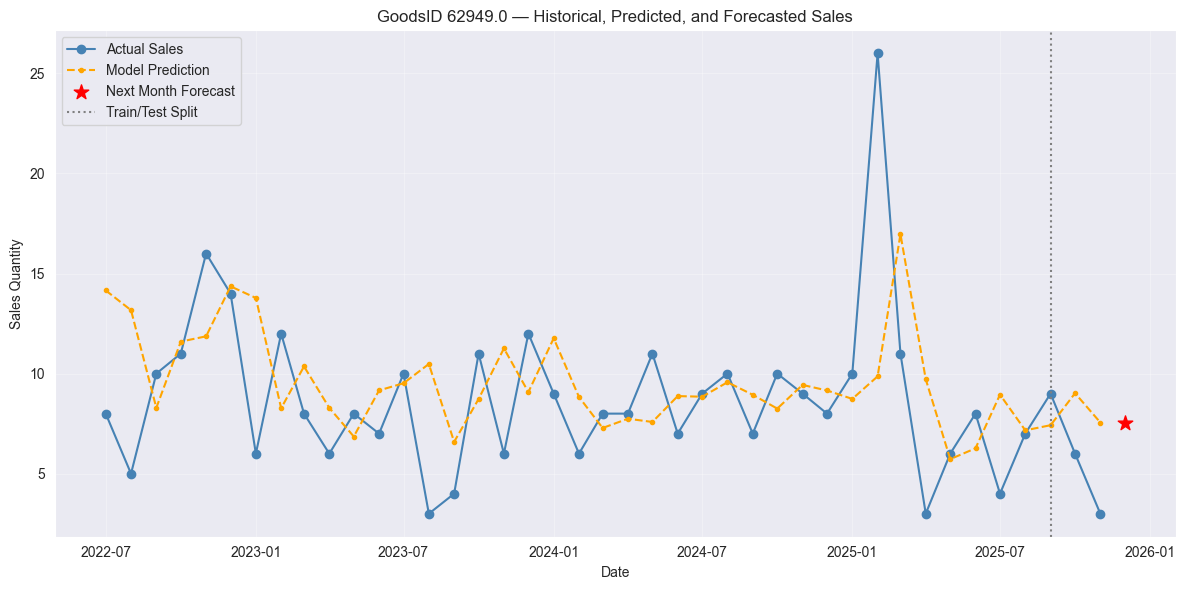

In [316]:
good_id = monthly[~monthly['lag_8'].isna()].sample(1).iloc[0,0]
print(f'GoodId = {good_id}')
plot_historical_and_predictions(good_id)